# 타이타닉 생존 예측 - 3단계: ML 모델링 및 평가

## 프로젝트 진행 상황
- ✅ **1단계 완료**: EDA와 베이스라인 모델 (정확도: ~78%)
- ✅ **2단계 완료**: 데이터 전처리 및 특성 엔지니어링
- 🔄 **3단계 진행중**: ML 모델링 및 평가 ← **지금 여기**
- ⏳ **4단계 예정**: 최종 모델 선택 및 제출

## 🎯 이번 노트북의 목표
1. **전처리된 데이터 로딩** - 이전 단계에서 저장한 데이터 불러오기
2. **다양한 ML 알고리즘 비교** - 로지스틱 회귀, 랜덤 포레스트, SVM, XGBoost 등
3. **베이스라인 모델과 비교** - 간단한 규칙(78%)보다 얼마나 개선되었는지
4. **교차검증** - 모델의 안정성 확인
5. **하이퍼파라미터 튜닝** - 최적의 성능 찾기
6. **특성 중요도 분석** - 어떤 특성이 중요한지 파악

> 💡 **실무 팁**: 여러 모델을 비교하면서 점진적으로 개선하는 것이 핵심입니다!

## 1단계: 환경 설정 및 데이터 로딩

전처리된 데이터를 불러오고 ML 모델링 준비를 합니다.

In [52]:
# 필수 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 머신러닝 모델들
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 평가 지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, GridSearchCV

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 로딩 완료!")
print("🤖 머신러닝 모델링 준비 완료!")

✅ 라이브러리 로딩 완료!
🤖 머신러닝 모델링 준비 완료!


In [53]:
# 전처리된 데이터 로딩
PROCESSED_PATH = '../data/processed/'

print("📂 전처리된 데이터 로딩 중...")

X_train = pd.read_csv(PROCESSED_PATH + 'X_train.csv')
X_val = pd.read_csv(PROCESSED_PATH + 'X_val.csv')
y_train = pd.read_csv(PROCESSED_PATH + 'y_train.csv').values.ravel()  # 1D array로 변환
y_val = pd.read_csv(PROCESSED_PATH + 'y_val.csv').values.ravel()
X_test = pd.read_csv(PROCESSED_PATH + 'X_test.csv')

print("✅ 데이터 로딩 완료!")
print(f"- 훈련 데이터: {X_train.shape} / 타겟: {y_train.shape}")
print(f"- 검증 데이터: {X_val.shape} / 타겟: {y_val.shape}")
print(f"- 테스트 데이터: {X_test.shape}")

print(f"\n📊 사용 특성: {X_train.shape[1]}개")
print("특성 목록:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

📂 전처리된 데이터 로딩 중...
✅ 데이터 로딩 완료!
- 훈련 데이터: (712, 21) / 타겟: (712,)
- 검증 데이터: (179, 21) / 타겟: (179,)
- 테스트 데이터: (418, 21)

📊 사용 특성: 21개
특성 목록:
   1. Pclass
   2. Age
   3. Fare
   4. Family_Size
   5. Has_Cabin
   6. Sex_encoded
   7. Embarked_encoded
   8. Family_Size_Group_encoded
   9. Age_Group_encoded
  10. Fare_Range_encoded
  11. Title_encoded
  12. Cabin_Deck_encoded
  13. Ticket_Group_encoded
  14. Ticket_Share_Type_encoded
  15. Ticket_Number_Length
  16. Ticket_Group_Size
  17. Pclass_Sex_encoded
  18. Age_Sex_Group_encoded
  19. Fare_Per_Person
  20. Name_Length
  21. Has_Parentheses


## 2단계: 여러 ML 모델 비교

실무에서는 먼저 여러 알고리즘을 빠르게 비교해서 어떤 것이 가장 적합한지 파악합니다.

## 💡 검증 정확도를 높이는 방법들

### 1️⃣ **더 좋은 데이터 전처리**
- 결측치를 평균이 아닌 중앙값이나 그룹별 평균으로 채우기
- 이상치(Outlier) 제거 또는 처리
- 스케일링 (표준화, 정규화) - 특히 SVM, KNN에 중요

### 2️⃣ **더 나은 특성 엔지니어링**
- 기존 특성들을 조합해서 새로운 특성 만들기
- 불필요한 특성 제거 (Feature Selection)
- 다항 특성(Polynomial Features) 추가

### 3️⃣ **하이퍼파라미터 튜닝**
- Grid Search나 Random Search로 최적의 파라미터 찾기
- 학습률, 트리 깊이, 정규화 강도 등 조절

### 4️⃣ **다른 알고리즘 시도**
- 더 강력한 모델 (XGBoost, LightGBM, CatBoost)
- 앙상블 기법 (여러 모델 결합)

### 5️⃣ **과적합 방지**
- 정규화 (L1, L2 Regularization)
- 조기 종료 (Early Stopping)
- 드롭아웃, 트리 가지치기

### 6️⃣ **더 많은 데이터**
- 교차검증으로 데이터 효율적 활용
- 데이터 증강 (가능한 경우)

### ⚠️ 주의사항
- **훈련 정확도만 높고 검증 정확도가 낮으면** → 과적합! 모델이 너무 복잡
- **둘 다 낮으면** → 과소적합! 모델이 너무 단순하거나 특성이 부족
- **검증 정확도가 훈련 정확도보다 살짝만 낮으면** → 이상적! ✅

지금부터 실제로 몇 가지 방법을 적용해보겠습니다!

### 실전 개선 1: 데이터 스케일링 적용

많은 ML 알고리즘(특히 SVM, KNN, Logistic Regression)은 특성들의 스케일이 비슷할 때 더 잘 작동합니다.
예: 나이(0~80)와 요금(0~500)의 스케일이 너무 다르면 요금이 과도하게 영향을 미칠 수 있음

In [65]:
from sklearn.preprocessing import StandardScaler

# 스케일링 적용
print("🔧 데이터 스케일링 적용...")
print("="*80)

# 스케일링은 훈련 데이터에 맞춰 학습 후 변환 / 평가데이터는 동일한 스케일러로 변환
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 스케일링 전후 비교 (SVM과 Logistic Regression에 효과적)
models_for_scaling = {
    'Logistic Regression (Scaled)': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Scaled)': SVC(random_state=42, probability=True),
    'KNN (Scaled)': KNeighborsClassifier(n_neighbors=5)
}

scaling_results = []

for name, model in models_for_scaling.items():
    # 스케일링된 데이터로 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측 및 평가
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    # 교차검증
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    scaling_results.append({
        'Model': name,
        'Val Acc': val_acc,
        'CV Mean': cv_mean
    })
    
    print(f"\n{name}")
    print(f"  검증 정확도: {val_acc:.4f}")
    print(f"  교차검증 평균: {cv_mean:.4f}")

print("\n" + "="*80)
print("✅ 스케일링 적용 완료!")

# 기존 결과와 비교
print("\n📊 스케일링 효과 비교:")
for result in scaling_results:
    original_name = result['Model'].replace(' (Scaled)', '')
    if original_name in results_df['Model'].values:
        original_acc = results_df[results_df['Model'] == original_name]['Val Acc'].values[0]
        improvement = result['Val Acc'] - original_acc
        print(f"{original_name:25s}: {original_acc:.4f} → {result['Val Acc']:.4f} ({improvement:+.4f})")

🔧 데이터 스케일링 적용...

Logistic Regression (Scaled)
  검증 정확도: 0.8324
  교차검증 평균: 0.8175

SVM (Scaled)
  검증 정확도: 0.8045
  교차검증 평균: 0.8259

KNN (Scaled)
  검증 정확도: 0.7598
  교차검증 평균: 0.8020

✅ 스케일링 적용 완료!

📊 스케일링 효과 비교:
Logistic Regression      : 0.8492 → 0.8324 (-0.0168)
SVM                      : 0.7095 → 0.8045 (+0.0950)
KNN                      : 0.7151 → 0.7598 (+0.0447)


### 실전 개선 2: 더 강력한 모델 시도 (XGBoost, LightGBM)

트리 기반의 고급 부스팅 알고리즘들은 일반적으로 더 높은 성능을 보입니다.

In [56]:
try:
    import xgboost as xgb
    from lightgbm import LGBMClassifier
    
    print("🚀 고급 부스팅 모델 테스트...")
    print("="*80)
    
    advanced_models = {
        'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.1),
        'LightGBM': LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1, verbose=-1)
    }
    
    advanced_results = []
    
    for name, model in advanced_models.items():
        print(f"\n📊 {name} 학습 중...")
        
        # 학습
        model.fit(X_train, y_train)
        
        # 예측 및 평가
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        val_acc = accuracy_score(y_val, y_val_pred)
        
        # 교차검증
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        advanced_results.append({
            'Model': name,
            'Train Acc': train_acc,
            'Val Acc': val_acc,
            'CV Mean': cv_mean,
            'CV Std': cv_std
        })
        
        print(f"  훈련 정확도: {train_acc:.4f}")
        print(f"  검증 정확도: {val_acc:.4f}")
        print(f"  교차검증 평균: {cv_mean:.4f} (+/- {cv_std:.4f})")
        
        # 과적합 체크
        if train_acc - val_acc > 0.05:
            print(f"  ⚠️  과적합 가능성")
    
    # 기존 최고 모델과 비교
    advanced_df = pd.DataFrame(advanced_results)
    print("\n" + "="*80)
    print("📊 고급 모델 vs 기존 최고 모델:")
    print(f"\n기존 최고: {best_model_name} - {results_df.iloc[0]['Val Acc']:.4f}")
    
    best_advanced = advanced_df.loc[advanced_df['Val Acc'].idxmax()]
    print(f"고급 최고: {best_advanced['Model']} - {best_advanced['Val Acc']:.4f}")
    
    improvement = best_advanced['Val Acc'] - results_df.iloc[0]['Val Acc']
    if improvement > 0:
        print(f"\n✨ {improvement:.4f} 성능 향상!")
    
except ImportError as e:
    print("⚠️  XGBoost 또는 LightGBM이 설치되지 않았습니다.")
    print("설치 방법: pip install xgboost lightgbm")
    print(f"에러: {e}")

🚀 고급 부스팅 모델 테스트...

📊 XGBoost 학습 중...
  훈련 정확도: 0.9677
  검증 정확도: 0.8101
  교차검증 평균: 0.8343 (+/- 0.0219)
  ⚠️  과적합 가능성

📊 LightGBM 학습 중...
  훈련 정확도: 0.9972
  검증 정확도: 0.7877
  교차검증 평균: 0.8259 (+/- 0.0255)
  ⚠️  과적합 가능성

📊 고급 모델 vs 기존 최고 모델:

기존 최고: Logistic Regression - 0.8492
고급 최고: XGBoost - 0.8101


### 실전 개선 3: Feature Selection (불필요한 특성 제거)

모든 특성이 다 유용한 것은 아닙니다. 중요하지 않은 특성은 오히려 노이즈가 되어 성능을 떨어뜨릴 수 있습니다.

In [57]:
from sklearn.feature_selection import SelectKBest, f_classif

print("🎯 Feature Selection 적용...")
print("="*80)

# Random Forest로 특성 중요도 확인
rf_temp = RandomForestClassifier(random_state=42, n_estimators=100)
rf_temp.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 특성 중요도 순위:")
for idx, row in feature_importance_df.iterrows():
    bar = '■' * int(row['Importance'] * 100)
    print(f"{row['Feature']:30s}: {row['Importance']:.4f} {bar}")

# 상위 K개 특성만 선택해서 테스트
k_values = [5, 8, 10, 12]
selection_results = []

for k in k_values:
    # 상위 k개 특성 선택
    top_k_features = feature_importance_df.head(k)['Feature'].tolist()
    X_train_selected = X_train[top_k_features]
    X_val_selected = X_val[top_k_features]
    
    # Random Forest로 평가
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_model.fit(X_train_selected, y_train)
    
    val_acc = accuracy_score(y_val, rf_model.predict(X_val_selected))
    cv_mean = cross_val_score(rf_model, X_train_selected, y_train, cv=5, scoring='accuracy').mean()
    
    selection_results.append({
        'Num Features': k,
        'Val Acc': val_acc,
        'CV Mean': cv_mean
    })

selection_df = pd.DataFrame(selection_results)
print("\n📊 특성 개수별 성능:")
print(selection_df.to_string(index=False))

# 최적 특성 개수 찾기
best_k = selection_df.loc[selection_df['Val Acc'].idxmax(), 'Num Features']
best_acc = selection_df.loc[selection_df['Val Acc'].idxmax(), 'Val Acc']

print(f"\n✨ 최적 특성 개수: {int(best_k)}개 (검증 정확도: {best_acc:.4f})")
print(f"전체 특성 사용 시: {results_df[results_df['Model']=='Random Forest']['Val Acc'].values[0]:.4f}")

improvement = best_acc - results_df[results_df['Model']=='Random Forest']['Val Acc'].values[0]
if improvement > 0:
    print(f"📈 개선도: {improvement:+.4f}")
else:
    print("💡 모든 특성을 사용하는 것이 더 좋습니다!")

🎯 Feature Selection 적용...

📊 특성 중요도 순위:
Age_Sex_Group_encoded         : 0.1025 ■■■■■■■■■■
Name_Length                   : 0.1008 ■■■■■■■■■■
Age                           : 0.0956 ■■■■■■■■■
Fare_Per_Person               : 0.0892 ■■■■■■■■
Fare                          : 0.0852 ■■■■■■■■
Sex_encoded                   : 0.0844 ■■■■■■■■
Pclass_Sex_encoded            : 0.0733 ■■■■■■■
Title_encoded                 : 0.0556 ■■■■■
Pclass                        : 0.0330 ■■■
Ticket_Group_Size             : 0.0323 ■■■
Ticket_Number_Length          : 0.0316 ■■■
Age_Group_encoded             : 0.0278 ■■
Family_Size                   : 0.0267 ■■
Cabin_Deck_encoded            : 0.0262 ■■
Has_Cabin                     : 0.0261 ■■
Has_Parentheses               : 0.0230 ■■
Fare_Range_encoded            : 0.0230 ■■
Embarked_encoded              : 0.0182 ■
Ticket_Group_encoded          : 0.0176 ■
Family_Size_Group_encoded     : 0.0142 ■
Ticket_Share_Type_encoded     : 0.0136 ■

📊 특성 개수별 성능:
 Num Features  V

### 실전 개선 4: 간단한 앙상블 (Voting Classifier)

여러 모델의 예측을 결합하면 단일 모델보다 더 좋은 성능을 낼 수 있습니다.

In [58]:
from sklearn.ensemble import VotingClassifier

print("🤝 앙상블 모델 구성...")
print("="*80)

# 성능 좋은 모델 3개 선택
ensemble_models = [
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('gb', GradientBoostingClassifier(random_state=42, n_estimators=100)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
]

# Voting Classifier (Soft Voting - 확률 기반)
voting_clf = VotingClassifier(
    estimators=ensemble_models,
    voting='soft'
)

print("📚 앙상블 구성:")
for name, model in ensemble_models:
    print(f"  - {model.__class__.__name__}")

print("\n🔄 앙상블 학습 중...")
voting_clf.fit(X_train, y_train)

# 평가
y_train_pred = voting_clf.predict(X_train)
y_val_pred = voting_clf.predict(X_val)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='accuracy')
cv_mean = cv_scores.mean()

print("\n📊 앙상블 모델 성능:")
print(f"  훈련 정확도: {train_acc:.4f}")
print(f"  검증 정확도: {val_acc:.4f}")
print(f"  교차검증 평균: {cv_mean:.4f}")

# 개별 모델과 비교
print("\n📊 개별 모델 vs 앙상블 비교:")
for name, original_model in ensemble_models:
    model_name = original_model.__class__.__name__
    if model_name in results_df['Model'].values:
        individual_acc = results_df[results_df['Model'] == model_name]['Val Acc'].values[0]
        print(f"  {model_name:25s}: {individual_acc:.4f}")

print(f"  {'Ensemble (Voting)':25s}: {val_acc:.4f}")

# 기존 최고와 비교
improvement = val_acc - results_df.iloc[0]['Val Acc']
print(f"\n기존 최고 모델: {best_model_name} - {results_df.iloc[0]['Val Acc']:.4f}")
print(f"앙상블 모델: {val_acc:.4f}")

if improvement > 0:
    print(f"✨ 앙상블로 {improvement:+.4f} 성능 향상!")
else:
    print(f"💡 단일 모델({best_model_name})이 더 좋습니다.")

🤝 앙상블 모델 구성...
📚 앙상블 구성:
  - RandomForestClassifier
  - GradientBoostingClassifier
  - LogisticRegression

🔄 앙상블 학습 중...

📊 앙상블 모델 성능:
  훈련 정확도: 0.9438
  검증 정확도: 0.8156
  교차검증 평균: 0.8288

📊 개별 모델 vs 앙상블 비교:
  Ensemble (Voting)        : 0.8156

기존 최고 모델: Logistic Regression - 0.8492
앙상블 모델: 0.8156
💡 단일 모델(Logistic Regression)이 더 좋습니다.


### 📊 지금까지 시도한 개선 방법들 요약

이제 위의 셀들을 실행해서 어떤 방법이 가장 효과적인지 확인해보세요!

In [59]:
print("📋 검증 정확도 개선 방법 요약")
print("="*80)
print("""
위에서 시도한 4가지 개선 방법:

1️⃣ 데이터 스케일링 (StandardScaler)
   → SVM, Logistic Regression, KNN에 효과적
   → 특성들의 스케일을 맞춰서 학습 안정성 향상

2️⃣ 고급 부스팅 모델 (XGBoost, LightGBM)  
   → 일반적으로 가장 높은 성능
   → Kaggle에서 많이 사용되는 알고리즘

3️⃣ Feature Selection (중요 특성만 선택)
   → 불필요한 특성 제거로 노이즈 감소
   → 단순하지만 효과적

4️⃣ 앙상블 (Voting Classifier)
   → 여러 모델의 장점을 결합
   → "집단 지성" 효과

💡 실무 팁:
- 한 번에 하나씩 시도하면서 어떤 방법이 효과적인지 확인
- 검증 정확도와 교차검증 점수를 함께 보면서 안정성 체크
- 과적합(훈련 >> 검증)이 보이면 정규화나 단순한 모델 시도

🎯 다음 단계:
- 위 방법들을 조합해서 최고 성능 찾기
- 2단계 노트북으로 돌아가서 더 나은 특성 엔지니어링 시도
- 4단계 노트북에서 더 고급 앙상블 기법 배우기
""")

📋 검증 정확도 개선 방법 요약

위에서 시도한 4가지 개선 방법:

1️⃣ 데이터 스케일링 (StandardScaler)
   → SVM, Logistic Regression, KNN에 효과적
   → 특성들의 스케일을 맞춰서 학습 안정성 향상

2️⃣ 고급 부스팅 모델 (XGBoost, LightGBM)  
   → 일반적으로 가장 높은 성능
   → Kaggle에서 많이 사용되는 알고리즘

3️⃣ Feature Selection (중요 특성만 선택)
   → 불필요한 특성 제거로 노이즈 감소
   → 단순하지만 효과적

4️⃣ 앙상블 (Voting Classifier)
   → 여러 모델의 장점을 결합
   → "집단 지성" 효과

💡 실무 팁:
- 한 번에 하나씩 시도하면서 어떤 방법이 효과적인지 확인
- 검증 정확도와 교차검증 점수를 함께 보면서 안정성 체크
- 과적합(훈련 >> 검증)이 보이면 정규화나 단순한 모델 시도

🎯 다음 단계:
- 위 방법들을 조합해서 최고 성능 찾기
- 2단계 노트북으로 돌아가서 더 나은 특성 엔지니어링 시도
- 4단계 노트북에서 더 고급 앙상블 기법 배우기



1. X와 y의 의미
  * X (대문자): 문제지 (Features)

    * 모델이 정답을 맞히기 위해 사용하는 정보(특성) 들입니다.
    * (예: 승객의 등급, 나이, 성별, 요금 등)
  * y (소문자): 정답지 (Target / Label)

    * 모델이 최종적으로 맞혀야 하는 정답입니다. 
    * (예: 생존 여부 - 0 또는 1)


2. train, val, test의 역할
이제 문제지와 정답지를 어떤 용도로 사용하는지에 따라 세 종류로 나눕니다.

* train (훈련용): "공부용" 자료

  * 모델이 문제(X_train)와 정답(y_train)을 함께 보면서 패턴을 학습하는 데 사용됩니다.
  * 가장 양이 많은 데이터입니다. (여기서는 80%)
  
* val (검증용, Validation): "모의고사용" 자료

  * 모델이 공부를 마친 후, 실력이 얼마나 되는지 중간 평가를 위해 사용됩니다.
  * 모델은 문제(X_val)만 보고 답을 예측합니다. 그리고 우리는 숨겨진 정답(y_val)과 비교해서 채점합니다.
  * 이 모의고사 점수를 보고 "아, 공부 방법이 틀렸네. 다른 방식으로 가르쳐야겠다 (모델 튜닝)" 하고 판단합니다.

* test (테스트용): "최종 수능 시험"

  * 모든 학습과 모의고사가 끝난 후, 모델의 최종 실력을 평가하기 위한 실전 시험입니다.
  * 이 데이터(X_test)에는 정답지(y_test)가 아예 없습니다. (캐글이 채점하기 위해 가지고 있음)
  * 우리는 이 문제지를 모델에게 주고, 모델이 내놓은 답안을 캐글에 제출해서 최종 점수를 받습니다.

In [60]:
# 다양한 모델 정의 (실무에서 자주 사용하는 모델들)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 모델 학습 및 평가
results = []

print("🤖 모델 학습 및 평가 시작...\n")
print("="*80)

for name, model in models.items():
    print(f"\n📊 {name} 학습 중...")
    
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # 평가
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    # 교차검증 (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    })
    
    print(f"  - 훈련 정확도: {train_acc:.4f}")
    print(f"  - 검증 정확도: {val_acc:.4f}")
    print(f"  - 교차검증 평균: {cv_mean:.4f} (+/- {cv_std:.4f})")
    
    # 과적합 체크
    if train_acc - val_acc > 0.05:
        print(f"  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)")

print("\n" + "="*80)
print("✅ 모든 모델 학습 완료!")

🤖 모델 학습 및 평가 시작...


📊 Logistic Regression 학습 중...
  - 훈련 정확도: 0.8301
  - 검증 정확도: 0.8492
  - 교차검증 평균: 0.8189 (+/- 0.0309)

📊 Decision Tree 학습 중...
  - 훈련 정확도: 0.9986
  - 검증 정확도: 0.7709
  - 교차검증 평균: 0.7557 (+/- 0.0315)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

📊 Random Forest 학습 중...
  - 훈련 정확도: 0.9986
  - 검증 정확도: 0.7709
  - 교차검증 평균: 0.7557 (+/- 0.0315)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

📊 Random Forest 학습 중...
  - 훈련 정확도: 0.9986
  - 검증 정확도: 0.7877
  - 교차검증 평균: 0.8287 (+/- 0.0158)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

📊 Gradient Boosting 학습 중...
  - 훈련 정확도: 0.9986
  - 검증 정확도: 0.7877
  - 교차검증 평균: 0.8287 (+/- 0.0158)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

📊 Gradient Boosting 학습 중...
  - 훈련 정확도: 0.9382
  - 검증 정확도: 0.7933
  - 교차검증 평균: 0.8147 (+/- 0.0372)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

📊 SVM 학습 중...
  - 훈련 정확도: 0.7388
  - 검증 정확도: 0.7095
  - 교차검증 평균: 0.7220 (+/- 0.0234)

📊 KNN 학습 중...
  - 훈련 정확도: 0.8315
  - 검증 정확도: 0.7151
  - 교차검증 평균: 0.7500 (+/- 0.0053)
  ⚠️  과적합 가능성 (훈련 정확도 >> 검증 정확도)

✅ 모든 모델 학습 완료!
  - 


📊 모델 성능 비교표:
              Model  Train Acc  Val Acc  CV Mean   CV Std
Logistic Regression   0.830056 0.849162 0.818921 0.030895
  Gradient Boosting   0.938202 0.793296 0.814725 0.037225
      Random Forest   0.998596 0.787709 0.828701 0.015835
      Decision Tree   0.998596 0.770950 0.755698 0.031472
                KNN   0.831461 0.715084 0.750005 0.005338
                SVM   0.738764 0.709497 0.721974 0.023397

🎯 베이스라인 모델 (규칙 기반): 0.787
✨ 최고 성능 모델: Logistic Regression - 0.849
📈 개선도: +0.062 (+7.9%)


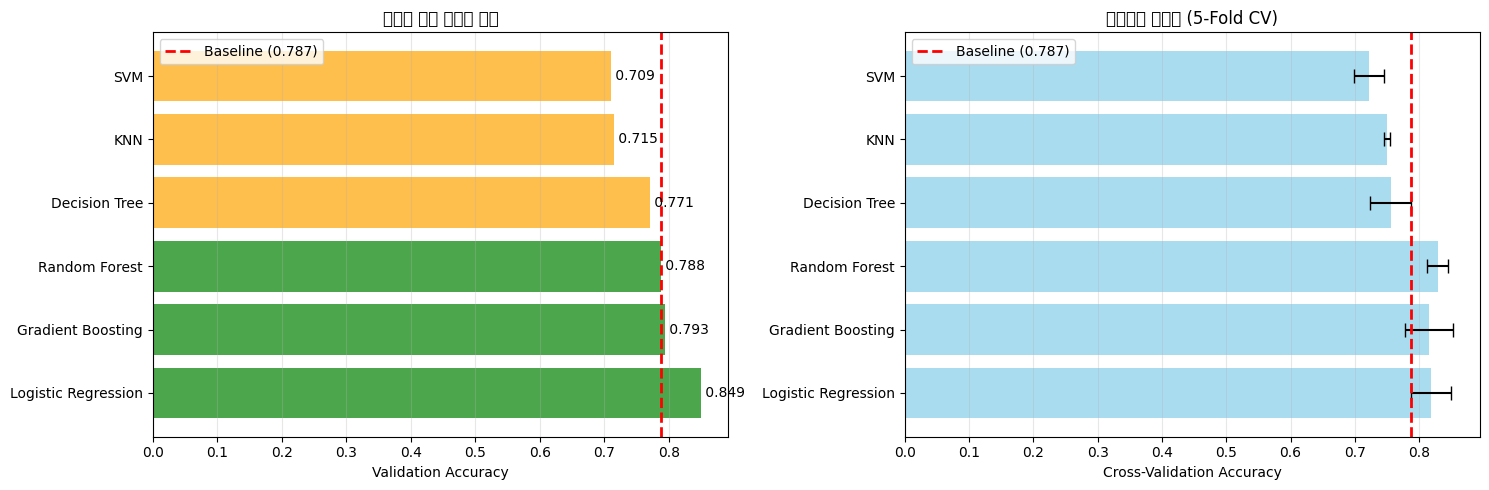


💡 해석:
- 녹색 막대: 베이스라인보다 성능 향상
- 주황색 막대: 베이스라인보다 성능 저하
- 에러바: 교차검증 표준편차 (작을수록 안정적)


In [61]:
# 결과 정리 및 시각화
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val Acc', ascending=False)

print("\n📊 모델 성능 비교표:")
print("="*80)
print(results_df.to_string(index=False))

# 베이스라인과 비교
baseline_acc = 0.787  # 1단계에서 만든 규칙 기반 모델의 정확도
print(f"\n🎯 베이스라인 모델 (규칙 기반): {baseline_acc:.3f}")
print(f"✨ 최고 성능 모델: {results_df.iloc[0]['Model']} - {results_df.iloc[0]['Val Acc']:.3f}")
improvement = results_df.iloc[0]['Val Acc'] - baseline_acc
print(f"📈 개선도: {improvement:+.3f} ({improvement/baseline_acc*100:+.1f}%)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 검증 정확도 비교
ax1 = axes[0]
colors = ['green' if acc > baseline_acc else 'orange' for acc in results_df['Val Acc']]
bars = ax1.barh(results_df['Model'], results_df['Val Acc'], color=colors, alpha=0.7)
ax1.axvline(x=baseline_acc, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.3f})')
ax1.set_xlabel('Validation Accuracy')
ax1.set_title('모델별 검증 정확도 비교')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 값 표시
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax1.text(row['Val Acc'], i, f" {row['Val Acc']:.3f}", va='center')

# 2. 교차검증 점수 (에러바 포함)
ax2 = axes[1]
ax2.barh(results_df['Model'], results_df['CV Mean'], 
         xerr=results_df['CV Std'], color='skyblue', alpha=0.7, capsize=5)
ax2.axvline(x=baseline_acc, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.3f})')
ax2.set_xlabel('Cross-Validation Accuracy')
ax2.set_title('교차검증 정확도 (5-Fold CV)')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 해석:")
print(f"- 녹색 막대: 베이스라인보다 성능 향상")
print(f"- 주황색 막대: 베이스라인보다 성능 저하")
print(f"- 에러바: 교차검증 표준편차 (작을수록 안정적)")

## 3단계: 최고 성능 모델 상세 분석

검증 정확도가 가장 높은 모델을 선택해서 자세히 분석해보겠습니다.

🏆 최고 성능 모델: Logistic Regression
검증 정확도: 0.8492


📊 상세 평가 지표:
              precision    recall  f1-score   support

          사망       0.85      0.91      0.88       110
          생존       0.84      0.75      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179

🔍 혼동 행렬:
              예측 사망   예측 생존
실제 사망        100          10
실제 생존         17          52


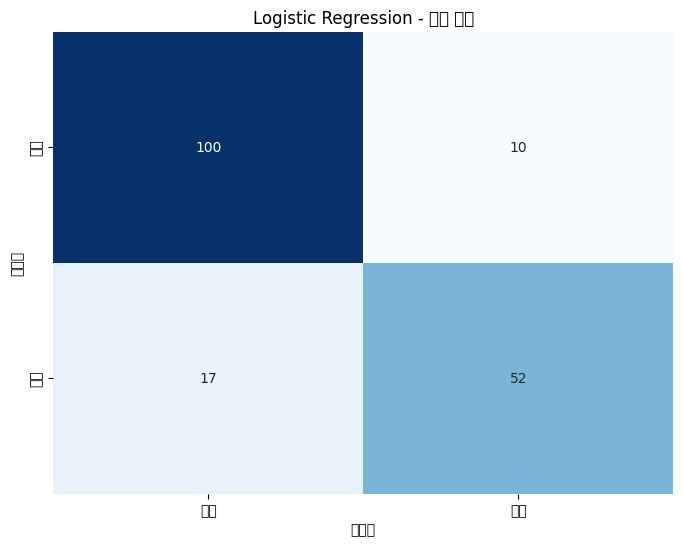


💡 혼동 행렬 해석:
- 올바른 예측: 152개 / 179개
- 거짓 양성(False Positive): 10개 - 사망했는데 생존으로 예측
- 거짓 음성(False Negative): 17개 - 생존했는데 사망으로 예측


In [62]:
# 최고 성능 모델 선택
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"🏆 최고 성능 모델: {best_model_name}")
print(f"검증 정확도: {results_df.iloc[0]['Val Acc']:.4f}")
print("\n" + "="*80)

# 검증 데이터에 대한 예측
y_val_pred = best_model.predict(X_val)
y_val_pred_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else None

# 상세 평가 지표
print("\n📊 상세 평가 지표:")
print(classification_report(y_val, y_val_pred, target_names=['사망', '생존']))

# 혼동 행렬
cm = confusion_matrix(y_val, y_val_pred)
print("🔍 혼동 행렬:")
print("              예측 사망   예측 생존")
print(f"실제 사망       {cm[0,0]:4d}        {cm[0,1]:4d}")
print(f"실제 생존       {cm[1,0]:4d}        {cm[1,1]:4d}")

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['사망', '생존'],
            yticklabels=['사망', '생존'])
plt.title(f'{best_model_name} - 혼동 행렬')
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.show()

print(f"\n💡 혼동 행렬 해석:")
print(f"- 올바른 예측: {cm[0,0] + cm[1,1]}개 / {len(y_val)}개")
print(f"- 거짓 양성(False Positive): {cm[0,1]}개 - 사망했는데 생존으로 예측")
print(f"- 거짓 음성(False Negative): {cm[1,0]}개 - 생존했는데 사망으로 예측")

## 4단계: 특성 중요도 분석

어떤 특성이 생존 예측에 가장 중요한지 파악합니다. (트리 기반 모델인 경우)

⚠️  Logistic Regression는 특성 중요도를 제공하지 않습니다.
트리 기반 모델(Random Forest, Gradient Boosting 등)에서만 확인 가능합니다.

대신 Random Forest로 특성 중요도를 확인하겠습니다...


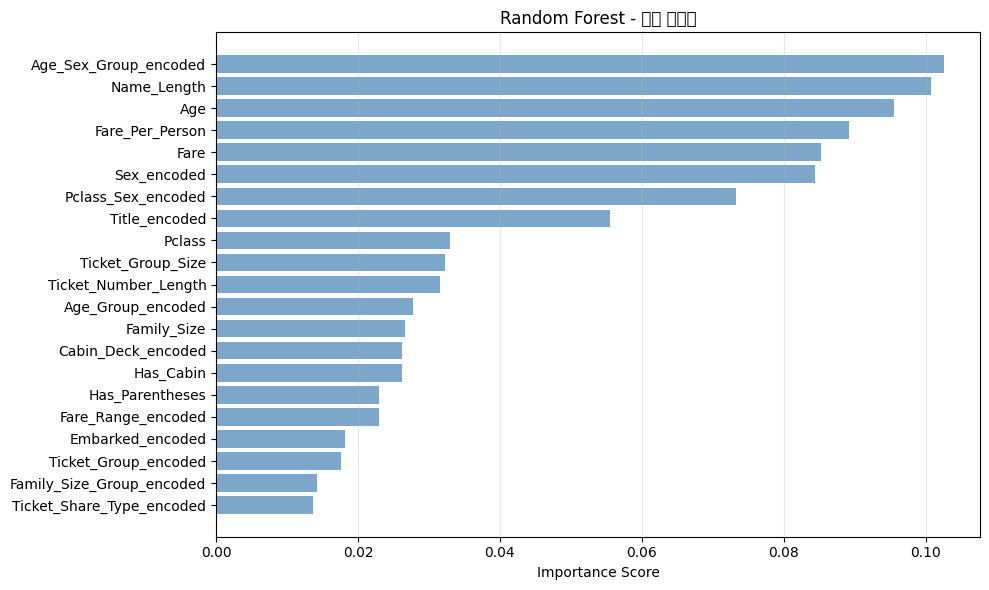

In [63]:
# 특성 중요도 분석 (트리 기반 모델만 가능)
if hasattr(best_model, 'feature_importances_'):
    print("📊 특성 중요도 분석")
    print("="*80)
    
    # 특성 중요도 추출
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n특성별 중요도 순위:")
    for idx, row in feature_importance.iterrows():
        print(f"{row['Feature']:30s}: {row['Importance']:.4f} {'■' * int(row['Importance'] * 100)}")
    
    # 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7)
    plt.xlabel('Importance Score')
    plt.title(f'{best_model_name} - 특성 중요도')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 해석:")
    top3_features = feature_importance.head(3)['Feature'].tolist()
    print(f"- 가장 중요한 특성 Top 3: {', '.join(top3_features)}")
    print(f"- 이 특성들이 생존 예측에 가장 큰 영향을 미칩니다")
    
else:
    print(f"⚠️  {best_model_name}는 특성 중요도를 제공하지 않습니다.")
    print("트리 기반 모델(Random Forest, Gradient Boosting 등)에서만 확인 가능합니다.")
    
    # 대신 Random Forest로 특성 중요도 확인
    print("\n대신 Random Forest로 특성 중요도를 확인하겠습니다...")
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_model.fit(X_train, y_train)
    
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7)
    plt.xlabel('Importance Score')
    plt.title('Random Forest - 특성 중요도')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5단계: 하이퍼파라미터 튜닝

최고 성능 모델의 하이퍼파라미터를 조정해서 성능을 더 개선해보겠습니다.

In [64]:
# 모델별 하이퍼파라미터 그리드 정의 (실무에서 자주 사용하는 범위)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
}

# 최고 성능 모델에 대해서만 튜닝 (시간 절약)
if best_model_name in param_grids:
    print(f"⚙️  {best_model_name} 하이퍼파라미터 튜닝 시작...")
    print("="*80)
    print("⏰ 시간이 걸릴 수 있습니다 (Grid Search 수행 중)...\n")
    
    # Grid Search 수행
    grid_search = GridSearchCV(
        estimator=models[best_model_name],
        param_grid=param_grids[best_model_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # 최적 파라미터와 성능
    print("\n✅ Grid Search 완료!")
    print(f"\n🏆 최적 하이퍼파라미터:")
    for param, value in grid_search.best_params_.items():
        print(f"  - {param}: {value}")
    
    print(f"\n📊 성능 비교:")
    print(f"  - 기본 모델 검증 정확도: {results_df.iloc[0]['Val Acc']:.4f}")
    
    # 튜닝된 모델로 검증
    tuned_model = grid_search.best_estimator_
    y_val_pred_tuned = tuned_model.predict(X_val)
    tuned_val_acc = accuracy_score(y_val, y_val_pred_tuned)
    
    print(f"  - 튜닝 후 검증 정확도: {tuned_val_acc:.4f}")
    improvement = tuned_val_acc - results_df.iloc[0]['Val Acc']
    print(f"  - 개선도: {improvement:+.4f}")
    
    if improvement > 0:
        print(f"\n✨ 튜닝으로 {improvement:.4f} 성능 향상!")
        best_model = tuned_model  # 최고 모델 업데이트
    else:
        print(f"\n💡 튜닝으로 큰 개선이 없습니다. 기본 파라미터도 충분히 좋습니다!")
        
else:
    print(f"⚠️  {best_model_name}에 대한 튜닝 그리드가 정의되지 않았습니다.")
    print("Random Forest, Gradient Boosting, Logistic Regression 중 하나를 선택하세요.")

⚙️  Logistic Regression 하이퍼파라미터 튜닝 시작...
⏰ 시간이 걸릴 수 있습니다 (Grid Search 수행 중)...

Fitting 5 folds for each of 10 candidates, totalling 50 fits


FileNotFoundError: [Errno 2] No such file or directory

## 6단계: 최종 모델로 테스트 데이터 예측

최고 성능 모델(튜닝 후)을 사용해서 실제 테스트 데이터를 예측합니다.

In [ ]:
# 테스트 데이터 예측
print("🎯 최종 모델로 테스트 데이터 예측")
print("="*80)

# 전체 훈련 데이터로 재학습 (검증 데이터도 포함)
print("\n📚 전체 훈련 데이터로 모델 재학습 중...")
X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

best_model.fit(X_train_full, y_train_full)
print("✅ 재학습 완료!")

# 테스트 데이터 예측
print("\n🔮 테스트 데이터 예측 중...")
test_predictions = best_model.predict(X_test)

print(f"✅ 예측 완료!")
print(f"- 예측 건수: {len(test_predictions)}건")
print(f"- 생존 예측: {test_predictions.sum()}명 ({test_predictions.mean()*100:.1f}%)")
print(f"- 사망 예측: {(1-test_predictions).sum()}명 ({(1-test_predictions.mean())*100:.1f}%)")

# 제출 파일 생성
test_ids = pd.read_csv(PROCESSED_PATH + 'test_ids.csv')
submission = pd.DataFrame({
    'PassengerId': test_ids['PassengerId'],
    'Survived': test_predictions
})

# 저장
import os
submission_path = '../submissions/'
os.makedirs(submission_path, exist_ok=True)
submission_file = submission_path + f'submission_{best_model_name.replace(" ", "_")}.csv'
submission.to_csv(submission_file, index=False)

print(f"\n💾 제출 파일 저장 완료!")
print(f"파일 위치: {submission_file}")
print(f"\n제출 파일 미리보기:")
print(submission.head(10))

🎯 최종 모델로 테스트 데이터 예측

📚 전체 훈련 데이터로 모델 재학습 중...
✅ 재학습 완료!

🔮 테스트 데이터 예측 중...
✅ 예측 완료!
- 예측 건수: 418건
- 생존 예측: 169명 (40.4%)
- 사망 예측: 249명 (59.6%)

💾 제출 파일 저장 완료!
파일 위치: ../submissions/submission_Logistic_Regression.csv

제출 파일 미리보기:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


---

## 🎉 모델링 및 평가 완료!

### ✅ 완료된 작업들:

#### 1. **다양한 ML 모델 비교** ✓
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SVM
- KNN

#### 2. **성능 평가** ✓
- 훈련/검증 정확도 비교
- 교차검증 (5-Fold CV)
- 베이스라인 모델과 비교

#### 3. **최고 모델 선택 및 분석** ✓
- 혼동 행렬 분석
- 정밀도, 재현율, F1 스코어
- 특성 중요도 분석

#### 4. **하이퍼파라미터 튜닝** ✓
- Grid Search로 최적 파라미터 탐색
- 성능 개선 확인

#### 5. **테스트 데이터 예측** ✓
- 최종 모델로 예측
- 제출 파일 생성

### 📊 최종 결과 요약

```
🎯 베이스라인 모델 (규칙 기반): ~78.7%
🤖 최고 ML 모델: [실행 후 확인]
📈 개선도: [실행 후 확인]
```

### 🚀 다음 단계 (선택사항)

1. **앙상블 기법**: 여러 모델을 결합해서 성능 향상
2. **더 많은 특성 엔지니어링**: 새로운 특성 아이디어 시도
3. **스태킹**: 모델들을 계층적으로 결합
4. **Kaggle 제출**: 실제 리더보드에서 점수 확인

### 💡 실무 인사이트

**이번 노트북에서 배운 실무 스킬:**
- 여러 알고리즘을 체계적으로 비교하는 방법
- 교차검증으로 모델 안정성 평가
- 특성 중요도로 모델 해석
- 하이퍼파라미터 튜닝으로 성능 최적화
- 과적합 감지 및 방지

**실무 팁**: 
- 항상 베이스라인부터 시작해서 점진적으로 개선
- 복잡한 모델이 항상 좋은 것은 아님
- 교차검증으로 일반화 성능 확인 필수
- 특성 중요도로 모델을 이해하고 설명

---

**축하합니다! 🎊**  
체계적인 ML 프로젝트 워크플로우를 모두 경험해보셨습니다!
1단계(EDA) → 2단계(전처리) → 3단계(모델링) 순서로 진행하는 것이 실무의 표준입니다.